------------------------------------

## Import the packages and load the data

In [1]:
%run ../../../Script/analysisLibraries

In [2]:
%run ../../../Script/pythonScripts.py

In [3]:
%matplotlib inline

In [4]:
%load_ext rpy2.ipython

In [5]:
import topo as tp

In [6]:
rcParams['figure.figsize']=(6,6) #rescale figures

Define sample name

In [7]:
sample = 'NUCLEI'

Load data Matrix

In [ ]:
adata = sc.read_mtx(f'../../../Data/Carl/{sample}/matrix.mtx')
adata = adata.T.copy()

Cells barcodes and gene names

In [ ]:
cells = pd.read_csv(f'../../../Data/Carl/{sample}/barcodes.tsv', header=None)

In [ ]:
adata.obs_names = cells.iloc[:,0]

In [ ]:
genes = pd.read_csv(f'../../../Data/Carl/{sample}/features.tsv', sep='\t', header=None)

In [ ]:
adata.var_names = genes.iloc[:,0]

Read spliced and unspliced data

In [ ]:
sdata = sc.read_mtx(f'../../../Data/Carl/{sample}_VELO/spliced_matrix.mtx')
sdata = sdata.T.copy()

Cells barcodes and gene names

In [ ]:
cells = pd.read_csv(f'../../../Data/Carl/{sample}_VELO/spliced_barcodes.tsv', header=None)

In [ ]:
sdata.obs_names = cells.iloc[:,0]

In [ ]:
genes = pd.read_csv(f'../../../Data/Carl/{sample}_VELO/spliced_features.tsv', sep='\t', header=None)

In [ ]:
sdata.var_names = genes.iloc[:,0]

In [ ]:
udata = sc.read_mtx(f'../../../Data/Carl/{sample}_VELO/unspliced_matrix.mtx')
udata = udata.T.copy()

Cells barcodes and gene names

In [ ]:
cells = pd.read_csv(f'../../../Data/Carl/{sample}_VELO/unspliced_barcodes.tsv', header=None)

In [ ]:
udata.obs_names = cells.iloc[:,0]

In [ ]:
genes = pd.read_csv(f'../../../Data/Carl/{sample}_VELO/unspliced_features.tsv', sep='\t', header=None)

In [ ]:
udata.var_names = genes.iloc[:,0]

Integrating spliced and unspliced matrices into the main data

In [ ]:
adata = adata[ np.intersect1d(adata.obs_names, sdata.obs_names), ].copy()
adata.layers['spliced'] = sdata[adata.obs_names,:].X.copy()
adata = adata[ np.intersect1d(adata.obs_names, udata.obs_names), ].copy()
adata.layers['unspliced'] = udata[adata.obs_names,:].X.copy()

In [ ]:
!mkdir -p ./write
adata.write(f'./write/{sample}.flt.1.h5ad')

Calculate spliced and unspliced proportions

In [ ]:
adata = sc.read(f'./write/{sample}.flt.1.h5ad')

Only considering the two last: ['.1', '.h5ad'].
Only considering the two last: ['.1', '.h5ad'].


In [ ]:
tot_spl = np.sum( adata.layers['spliced'], 1 )
tot_uns = np.sum( adata.layers['unspliced'], 1 )

adata.obs['spl_prop'] =  tot_spl/(tot_uns+tot_spl)
adata.obs['uns_prop'] =  tot_uns/(tot_uns+tot_spl)

We calculate the percentage of ribosomal protein genes and mitochondrial genes into each cell. We look at genes that contain `RPS` or `RPL` and `MT-` into their ID, and calculate their transcript proportion into each cell. We save the result as an observation into `.obs['perc_rp']` and `.obs['perc_mito']`

In [ ]:
import re
RP = [ re.match("^RP[SL]",i)!=None for i in adata.var_names]
perc_rp = np.sum( adata[:,RP].X, 1 ) / np.sum( adata.X, 1 )
adata.obs['perc_rp'] = perc_rp.copy()

In [ ]:
MT = ['MT' in i for i in adata.var_names]
perc_mito = np.sum( adata[:,MT].X, 1 ) / np.sum( adata.X, 1 )
adata.obs['perc_mito'] = perc_mito.copy()

Calculate various quality measures

In [ ]:
sc.pp.calculate_qc_metrics(adata, inplace=True)

# Denoising

using soupX on all matrices (spliced, unspliced, full)

Remove useless genes and drops with few transcripts

In [ ]:
adata.var_names = [i.replace("_","-") for i in adata.var_names]

In [ ]:
sc.pp.filter_genes(adata, min_cells=1)

Full dataset to check ambient RNA in soupX

In [ ]:
fulldata = sc.read_mtx(f'../../../Data/Carl/cellranger/{sample}_RAW/matrix.mtx')
fulldata = fulldata.T.copy()

In [ ]:
sc.pp.calculate_qc_metrics(fulldata, inplace=True)

Cells barcodes and gene names

In [ ]:
cells = pd.read_csv(f'../../../Data/Carl/cellranger/{sample}_RAW/barcodes.tsv', header=None)

In [ ]:
fulldata.obs_names = cells.iloc[:,0]

In [ ]:
genes = pd.read_csv(f'../../../Data/Carl/cellranger/{sample}_RAW/features.tsv', sep='\t', header=None)

In [ ]:
fulldata.var_names = genes.iloc[:,0]

In [ ]:
fulldata.var_names = [i.replace("_","-") for i in fulldata.var_names]

In [ ]:
np.sum(fulldata.obs['total_counts']>10)

144138

In [ ]:
fulldata2 = fulldata[fulldata.obs['total_counts']>10].copy()

In [ ]:
sc.pp.filter_genes(fulldata2, min_cells=1)

Intersect

In [ ]:
intersection = np.intersect1d(fulldata2.var_names, adata.var_names)

### SoupX on all counts

In [ ]:
rawMatrix = np.array(adata[:,intersection].X.todense().T, dtype='int16')
cells = adata[:,intersection].obs_names
genes = adata[:,intersection].var_names

In [ ]:
fullMatrix = np.array(fulldata2[:,intersection].X.todense().T, dtype='int16')
fullcells = fulldata2[:,intersection].obs_names
fullgenes = fulldata2[:,intersection].var_names

In [ ]:
%%R -i rawMatrix -i fullMatrix -i cells -i genes -i fullcells -i fullgenes

library(Seurat)
library(SoupX)


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

R[write to console]: Attaching SeuratObject



In [ ]:
%%R

colnames(fullMatrix) <- fullcells
rownames(fullMatrix) <- fullgenes
seurat_full <- CreateSeuratObject(fullMatrix)

colnames(rawMatrix) <- cells
rownames(rawMatrix) <- genes
seurat_filt <- CreateSeuratObject(rawMatrix)

Some normalization

In [ ]:
%%R

seurat_filt <- SCTransform(seurat_filt, verbose = TRUE, 
                         variable.features.n = 2000)
seurat_filt    <- RunPCA(seurat_filt, verbose = T)
seurat_filt    <- RunUMAP(seurat_filt, dims = 0:25, verbose = T)
seurat_filt    <- FindNeighbors(seurat_filt, dims = 0:25, verbose = T)
seurat_filt    <- FindClusters(seurat_filt, verbose=T)

R[write to console]: Calculating cell attributes from input UMI matrix: log_umi

R[write to console]: Variance stabilizing transformation of count matrix of size 25989 by 12402

R[write to console]: Model formula is y ~ log_umi

R[write to console]: Get Negative Binomial regression parameters per gene

R[write to console]: Using 2000 genes, 5000 cells



  |======================================================================| 100%


R[write to console]: Found 46 outliers - those will be ignored in fitting/regularization step


R[write to console]: Second step: Get residuals using fitted parameters for 25989 genes



  |======================================================================| 100%


R[write to console]: Computing corrected count matrix for 25989 genes



  |======================================================================| 100%


R[write to console]: Calculating gene attributes

R[write to console]: Wall clock passed: Time difference of 58.97815 secs

R[write to console]: Determine variable features

R[write to console]: Place corrected count matrix in counts slot

R[write to console]: Centering data matrix

  |                                                                            
  |                                                                      |   0%
  |                                                                            
  |=======================                                               |  33%
  |                                                                            
  |===============================================                       |  67%
  |                                                                            
  |======================================================================| 100%
R[write to console]: 

R[write to console]: Set default assay to SCT

R[writ

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 12402
Number of edges: 443795

Running Louvain algorithm...


R[write to console]: 0%   10   20   30   40   50   60   70   80   90   100%

R[write to console]: [----|----|----|----|----|----|----|----|----|----|

R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: *
R[write to console]: 

Maximum modularity in 10 random starts: 0.9062
Number of communities: 20
Elapsed time: 1 seconds


Setup and run soupX

In [ ]:
%%R
soup.channel <- SoupChannel(fullMatrix, rawMatrix)
meta    <- seurat_filt@meta.data
umap    <- seurat_filt@reductions$umap@cell.embeddings
soup.channel  <- setClusters(soup.channel, setNames(meta$seurat_clusters, rownames(meta)))
soup.channel  <- setDR(soup.channel, umap)
head(meta)

                    orig.ident nCount_RNA nFeature_RNA nCount_SCT nFeature_SCT
AAACCCAAGGACAGCT SeuratProject       3579         2284       3462         2284
AAACCCAAGGATAATC SeuratProject      10813         4700       3445         2261
AAACCCACAGATCCTA SeuratProject       6028         3572       4072         3193
AAACCCAGTGAATTAG SeuratProject       8927         3818       3659         2262
AAACCCAGTTAGTCGT SeuratProject       2767         1895       2781         1894
AAACGAAAGAGCATAT SeuratProject       1977         1484       2285         1484
                 SCT_snn_res.0.8 seurat_clusters
AAACCCAAGGACAGCT               1               1
AAACCCAAGGATAATC              11              11
AAACCCACAGATCCTA               8               8
AAACCCAGTGAATTAG              11              11
AAACCCAGTTAGTCGT               7               7
AAACGAAAGAGCATAT              12              12


In [ ]:
%%R

str(soup.channel)

List of 5
 $ toc        : int [1:27598, 1:12402] 0 0 0 0 0 0 0 0 0 0 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:27598] "A1BG" "A1CF" "A2M" "A2ML1" ...
  .. ..$ : chr [1:12402] "AAACCCAAGGACAGCT" "AAACCCAAGGATAATC" "AAACCCACAGATCCTA" "AAACCCAGTGAATTAG" ...
 $ metaData   :'data.frame':	12402 obs. of  4 variables:
  ..$ nUMIs   : num [1:12402] 3579 10813 6028 8927 2767 ...
  ..$ clusters: chr [1:12402] "1" "11" "8" "11" ...
  ..$ UMAP_1  : num [1:12402] -4.76 10.74 -3.5 10.55 1.57 ...
  ..$ UMAP_2  : num [1:12402] 7.91 3.77 -13.12 2.76 -4.74 ...
 $ nDropUMIs  : Named num [1:144138] 427 655 357 594 318 374 849 766 434 631 ...
  ..- attr(*, "names")= chr [1:144138] "AAACCCAAGACCAGAC" "AAACCCAAGACCTCCG" "AAACCCAAGACGTCCC" "AAACCCAAGACTACGG" ...
 $ soupProfile:'data.frame':	27598 obs. of  2 variables:
  ..$ est   : num [1:27598] 0.00 0.00 6.42e-05 0.00 0.00 ...
  ..$ counts: num [1:27598] 0 0 8 0 0 0 0 5 3 0 ...
 $ DR         : chr [1:2] "UMAP_1" "UMAP_2"
 - attr(*, "class")= c

R[write to console]: 3155 genes passed tf-idf cut-off and 381 soup quantile filter.  Taking the top 100.

R[write to console]: Using 961 independent estimates of rho.

R[write to console]: Estimated global rho of 0.19



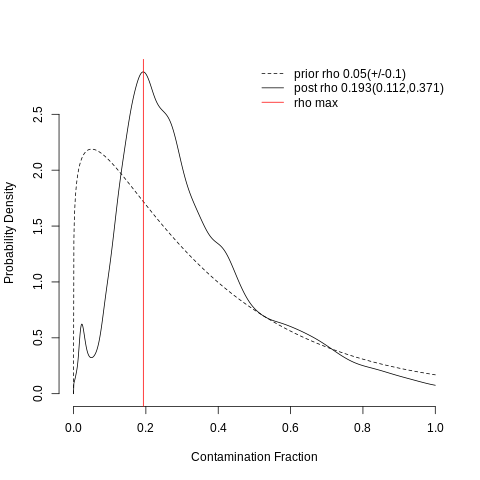

In [ ]:
%%R

soup.channel  <- autoEstCont(soup.channel)

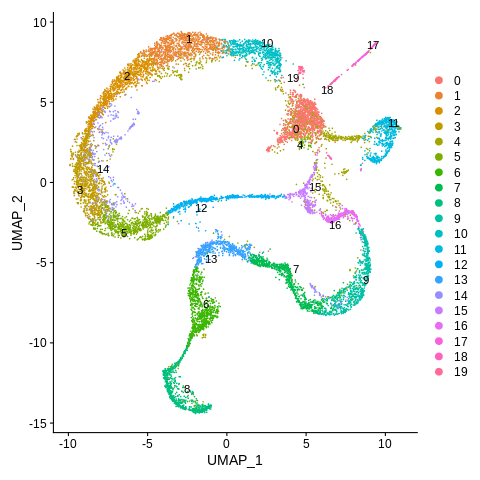

In [ ]:
%%R
# visualise UMAP embedding and clustering for 25 PCs
#     note - clusters not necessarily biologically relevant!
DimPlot(seurat_filt, label = T, repel = T)# + ggtitle("Unsupervised clustering")

Which genes had highest contamination. Preview and save the table.

In [ ]:
%%R

head(soup.channel$soupProfile[order(soup.channel$soupProfile$est, decreasing = T), ], n = 20)

                     est counts
PRM1         0.022710493   2830
PRM2         0.019877700   2477
KEF41-p10    0.015303502   1907
TNP1         0.012294161   1532
KEF41-p07    0.011242898   1401
KEF41-p11    0.009148397   1140
LOC104001214 0.004028504    502
MTRNR2L14    0.003587134    447
KEF41-p04    0.002961192    369
GPX4         0.002784644    347
HSP90AA1     0.002078452    259
SPINK2       0.002078452    259
CLU          0.002030302    253
GSTM3        0.001781530    222
HMGB4        0.001757455    219
COX7A2       0.001749430    218
KEF41-p06    0.001701281    212
CST3         0.001677206    209
UBB          0.001637082    204
UBA52        0.001572882    196


In [ ]:
%%R

write.csv(file='tables/contaminatedUMI.csv', soup.channel$soupProfile[order(soup.channel$soupProfile$est, decreasing = T), ])

In [ ]:
%%R -o adj_matrix

adj_matrix  <- adjustCounts(soup.channel, roundToInt = T)

R[write to console]: Expanding counts from 20 clusters to 12402 cells.



In [ ]:
%%R -o genesAdj

genesAdj <- rownames(soup.channel$toc)

In [ ]:
adj_matrix.T.shape == adata.shape

True

In [ ]:
adata = adata[:,genesAdj].copy()

In [ ]:
adata.layers['soupx_counts'] = np.array(adj_matrix.todense().T)

In [ ]:
adata.layers['raw_counts'] = adata.X.copy()

In [ ]:
adata.write(f'./write/{sample}.flt.2.h5ad')

## Visualize quality measure distributions

### One-dimensional distributions

In [10]:
adata = sc.read(f'../nuclei_analysis_LQ/write/{sample}.flt.2.h5ad')

Only considering the two last: ['.2', '.h5ad'].
Only considering the two last: ['.2', '.h5ad'].


In [11]:
adata.X = adata.layers['soupx_counts']

In [12]:
sc.pp.calculate_qc_metrics(adata, inplace=True)

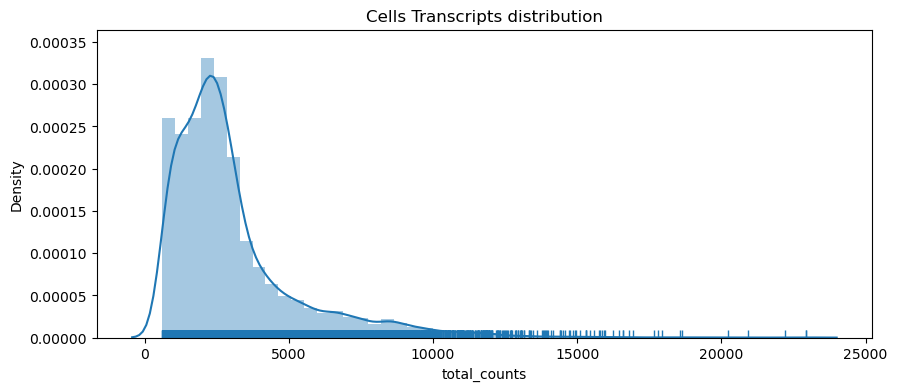

In [13]:
fig, ax = plt.subplots(1,1, figsize=(10,4))
fig1 = sns.distplot(adata.obs['total_counts'], bins=50, rug=True)
title1 = ax.set_title('Cells Transcripts distribution')

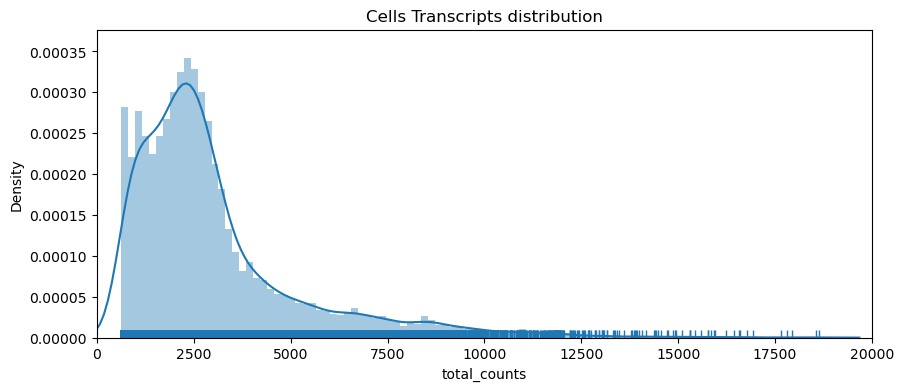

In [14]:
fig, ax = plt.subplots(1,1, figsize=(10,4))
fig1 = sns.distplot(adata[adata.obs['total_counts']<20000].obs['total_counts'], bins=100, rug=True)
plt.xlim(0, 20000)
title1 = ax.set_title('Cells Transcripts distribution')

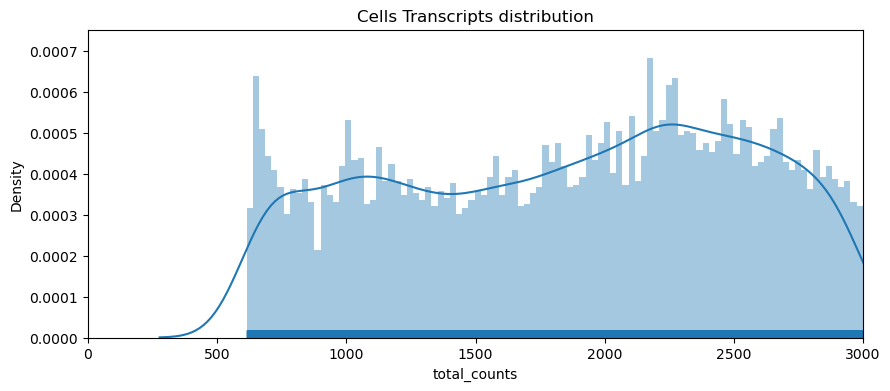

In [15]:
fig, ax = plt.subplots(1,1, figsize=(10,4))
fig1 = sns.distplot(adata[adata.obs['total_counts']<3000].obs['total_counts'], bins=100, rug=True)
plt.xlim(0, 3000)
title1 = ax.set_title('Cells Transcripts distribution')

We do a similar analysis with the thresholds for the number of genes detected in each droplet. 

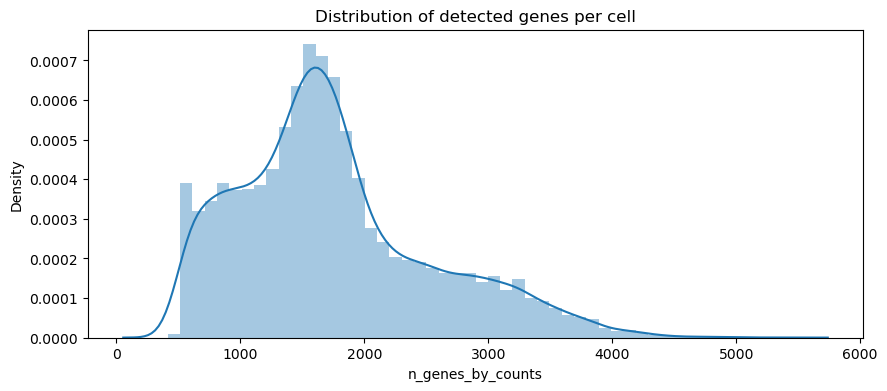

In [16]:
fig, ax = plt.subplots(1,1, figsize=(10,4))
fig1 = sns.distplot(adata.obs['n_genes_by_counts'], bins=50)
title1 = ax.set_title('Distribution of detected genes per cell')

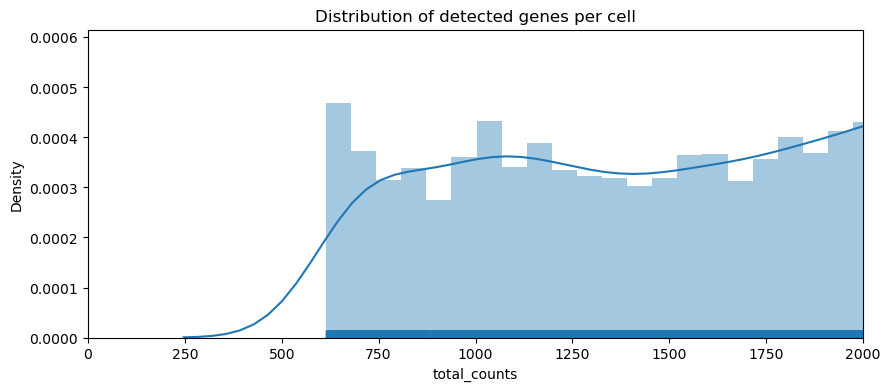

In [17]:
fig, ax = plt.subplots(1,1, figsize=(10,4))
fig1 = sns.distplot(adata[adata.obs['n_genes_by_counts']<2000].obs['total_counts'], bins=100, rug=True)
plt.xlim(0, 2000)
title1 = ax.set_title('Distribution of detected genes per cell')

**Mitochondrial content**: In this dataset there arebasically no cells with a high percentage of mitochondrial genes

In [18]:
#subsetting to see how many cells have percentage of mitochondrial genes above usual threshold of 10%
adata[ adata.obs['perc_mito']>0.1, : ].shape[0]

0

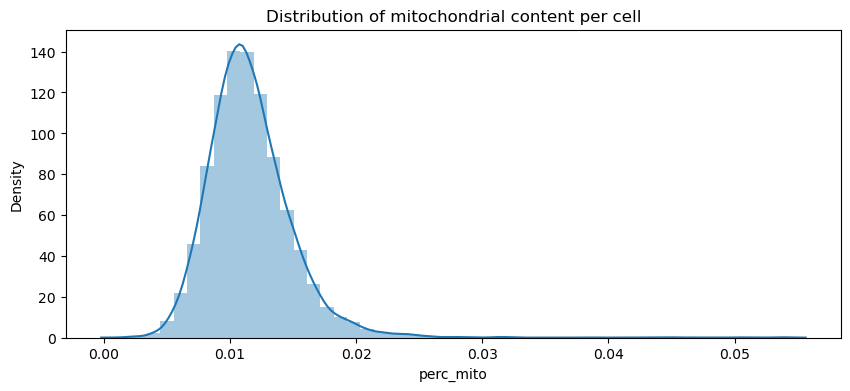

In [19]:
fig, ax = plt.subplots(1,1, figsize=(10,4))
fig1 = sns.distplot(adata.obs['perc_mito'], bins=50)
title1 = ax.set_title('Distribution of mitochondrial content per cell')

**Ribosomal content**: The percentage of ribosomal protein genes is also very low, so we do not really need to do any filtering on that as well

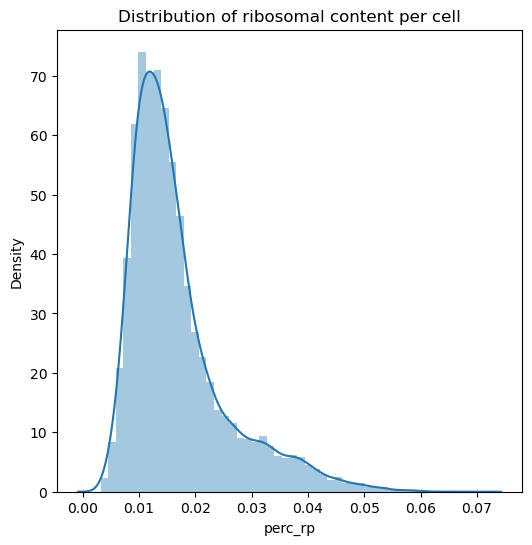

In [20]:
ax = sns.distplot(adata.obs['perc_rp'], bins=50)
x = ax.set_title('Distribution of ribosomal content per cell')

We can see how many droplets contain more than 5% of ribosomal protein transcripts

In [21]:
f'Max ribosomal transcript threshold overstepped by {sum(adata.obs["perc_rp"]>0.05)} cells'

'Max ribosomal transcript threshold overstepped by 63 cells'

**Spliced content**: We can observe two peaks. We want to remove the one on the extreme right of the plot, for example with a threshold of 0.8

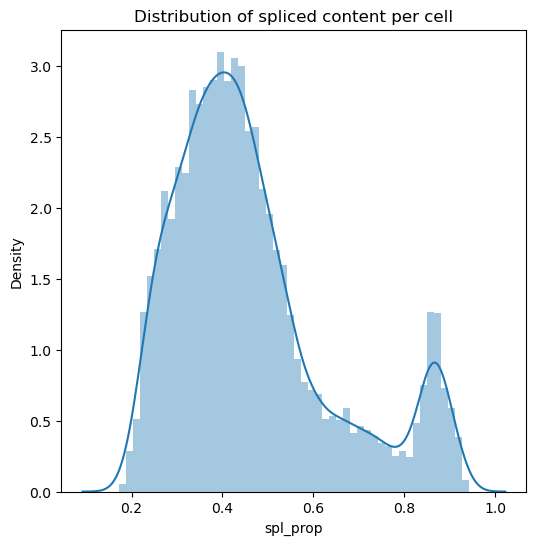

In [22]:
ax = sns.distplot(adata.obs['spl_prop'], bins=50)
x = ax.set_title('Distribution of spliced content per cell')

### Bidimensional patterns


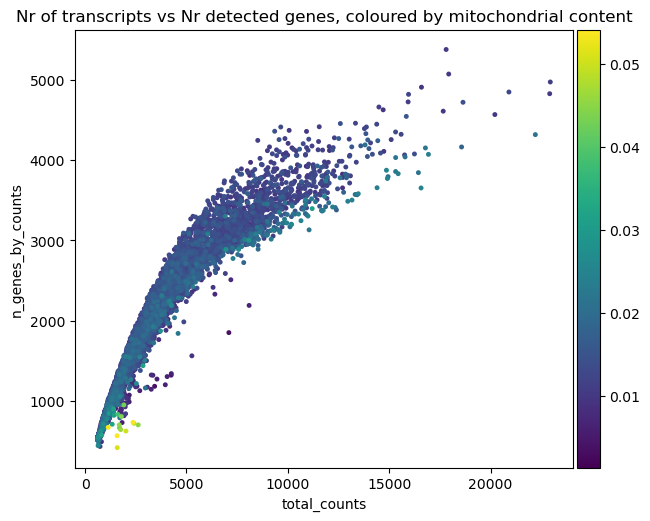

In [23]:
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color='perc_mito', 
              title ='Nr of transcripts vs Nr detected genes, coloured by mitochondrial content',
             size=50)

### Abnormal amount of transcripts from a gene

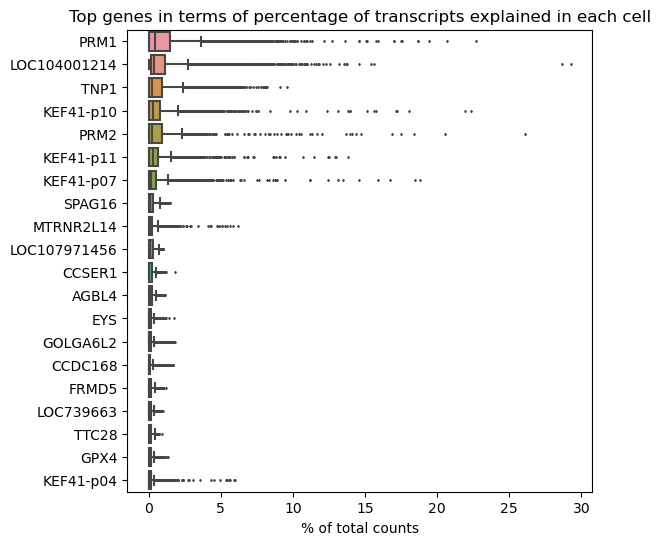

In [24]:
fig, ax = plt.subplots(1,1)
ax.set_title('Top genes in terms of percentage of transcripts explained in each cell')
fig = sc.pl.highest_expr_genes(adata, n_top=20, ax=ax)

You can save the percentages of transcripts expressing some genes identified above. We do not need this here, but we run the code just for completeness.

In [25]:
GENES = ['PRM1', 'PRM2', 'LOC104001214', 'KEF41-p07', 'KEF41-p04', 'MTRNR2L14']

for G in GENES:
    perc = np.sum( adata[:,G].X, 1 ) / np.sum( adata.X, 1 )
    adata.obs[f'perc_{G}'] = perc.copy()

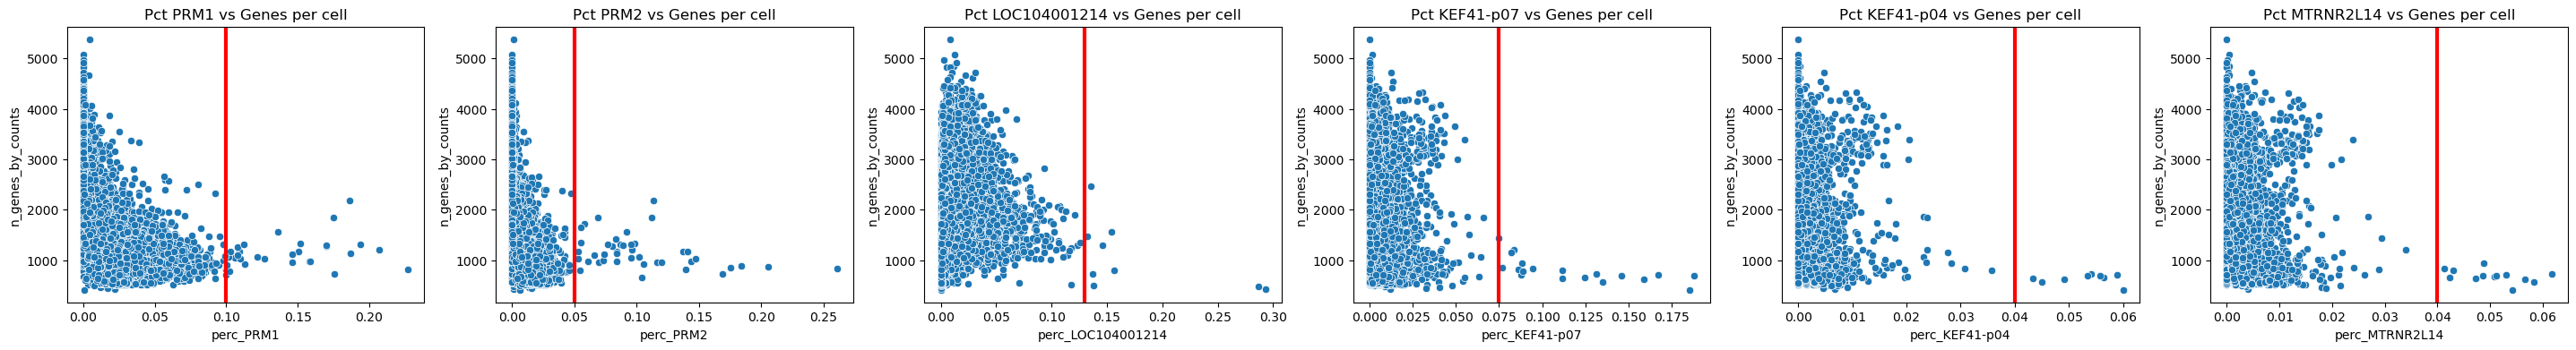

In [26]:
#some thresholds based on the plots below
thresholds = [.1, .05, .13, .075, .04, .04]

#do the plots and check the thresholds you prefere, and change them in the code line above to plot again
L = len(thresholds)
fig, ax = plt.subplots(1, L, figsize=(L*6,4))



#ax.set_title('Top genes in terms of percentage of transcripts explained in each cell')
for G,T,A in zip(GENES, thresholds, ax):
    A.set_title(f'Pct {G} vs Genes per cell')
    fig1 = sns.scatterplot( x=adata.obs[f'perc_{G}'], y=adata.obs['n_genes_by_counts'], ax=A )
    fig1.axvline(x=T, lw=3, c='r')

How many cells would we remove with these thresholds?

In [27]:
#find droplets above one of the thresholds
total = np.zeros( adata.shape[0], dtype='bool8' )
for G,T in zip(GENES, thresholds):
    total = (total) | (adata.obs[f'perc_{G}']>T)

#save the identifier into the data
adata.obs['genes_threshold_filter'] = pd.Categorical(total).copy()

In [28]:
#count all the cells above thresholds
f'You will filter out in total {sum(total)} cells'

'You will filter out in total 76 cells'

## Choosing thresholds and filtering

We now establish all the filtering values discussed until now by looking at distributions.

In [29]:
MIN_COUNTS = 1300  #minimum number of transcripts per cell
MAX_COUNTS = 12500 #maximum number of transcripts per cell
MIN_GENES = 1300   #minimum number of genes per cell
MAX_GENES = 5000   #maximum number of genes per cell


We can also plot all the points we are going to filter out. We save `all_filters` in the data. This contains all filters defined until now to detect points to remove.

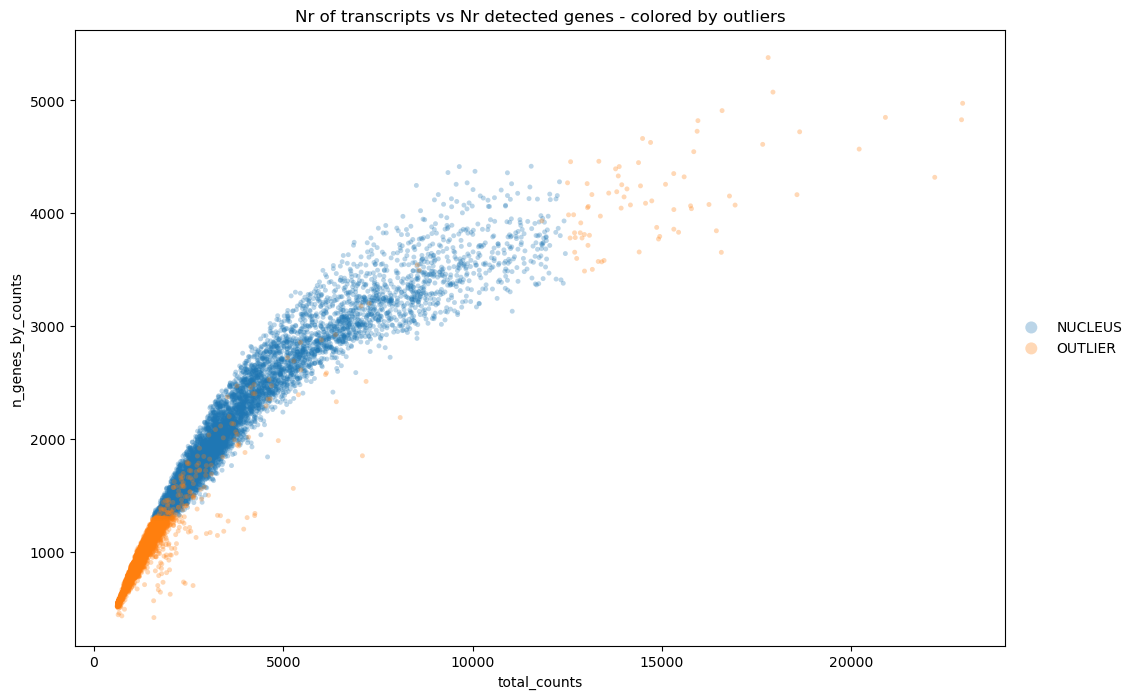

In [30]:
#define an indicator to remove cells
all_filters = (adata.obs['total_counts']>MAX_COUNTS) | (adata.obs['total_counts']<MIN_COUNTS) | \
            (adata.obs['n_genes_by_counts']<MIN_GENES) | (adata.obs['n_genes_by_counts']>MAX_GENES) | \
            (adata.obs['perc_KEF41-p07']>0.075) | (adata.obs['perc_KEF41-p04']>0.04) | (adata.obs['perc_MTRNR2L14']>0.04) | \
            (adata.obs['perc_PRM1']>0.1) | (adata.obs['perc_PRM2']>0.05) | (adata.obs['perc_LOC104001214']>0.13) | \
             (adata.obs['spl_prop']>0.6)             

adata.obs['all_filters'] = pd.Categorical(all_filters).rename_categories(['NUCLEUS','OUTLIER'])
            
fig, ax = plt.subplots(1,1, figsize=(12,8))

#plot cells filtered by max transcripts
fig1 = sc.pl.scatter(adata, alpha=.3,
             x='total_counts', y='n_genes_by_counts', color='all_filters', size=50,
              title =f'Nr of transcripts vs Nr detected genes - colored by outliers', ax=ax, )

In [31]:
adata = adata[ adata.obs['all_filters'] == "NUCLEUS" ].copy()

sc.preprocessing.filter_genes(adata, min_cells=10)

### Filtering based on the spl prop in the clustering

In [32]:
adata2 = adata.copy()

In [33]:
sc.pp.normalize_total(adata2)
sc.pp.log1p(adata2)
sc.pp.highly_variable_genes(adata2)
sc.pp.scale(adata2, max_value=10)

In [34]:
sc.pp.pca(adata2, random_state=123)
sc.pp.neighbors(adata2, random_state=123)
sc.tl.umap(adata2, random_state=123)
sc.tl.leiden(adata2, resolution=.7, random_state=123)

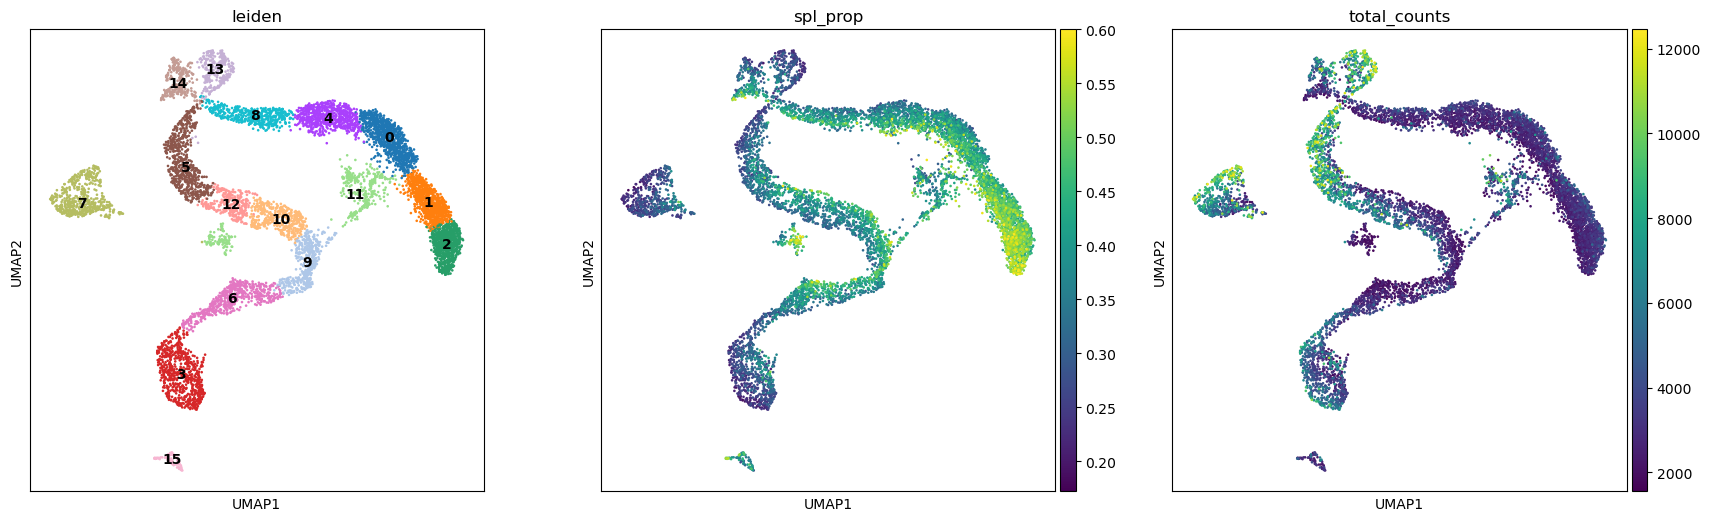

In [35]:
sc.pl.umap(adata2, color=['leiden','spl_prop','total_counts'], legend_loc='on data')

In [44]:
adata2.layers['UMI-soupx'] = adata2.layers['raw_counts'] - adata2.layers['soupx_counts'] 

In [45]:
adata2.obs['correction_quantity'] = np.log1p( np.sum( adata2.layers['UMI-soupx'], 1) )

In [46]:
adata2.obs['correction_AKAP4'] = np.array( adata2[:,'AKAP4'].layers['UMI-soupx'] )

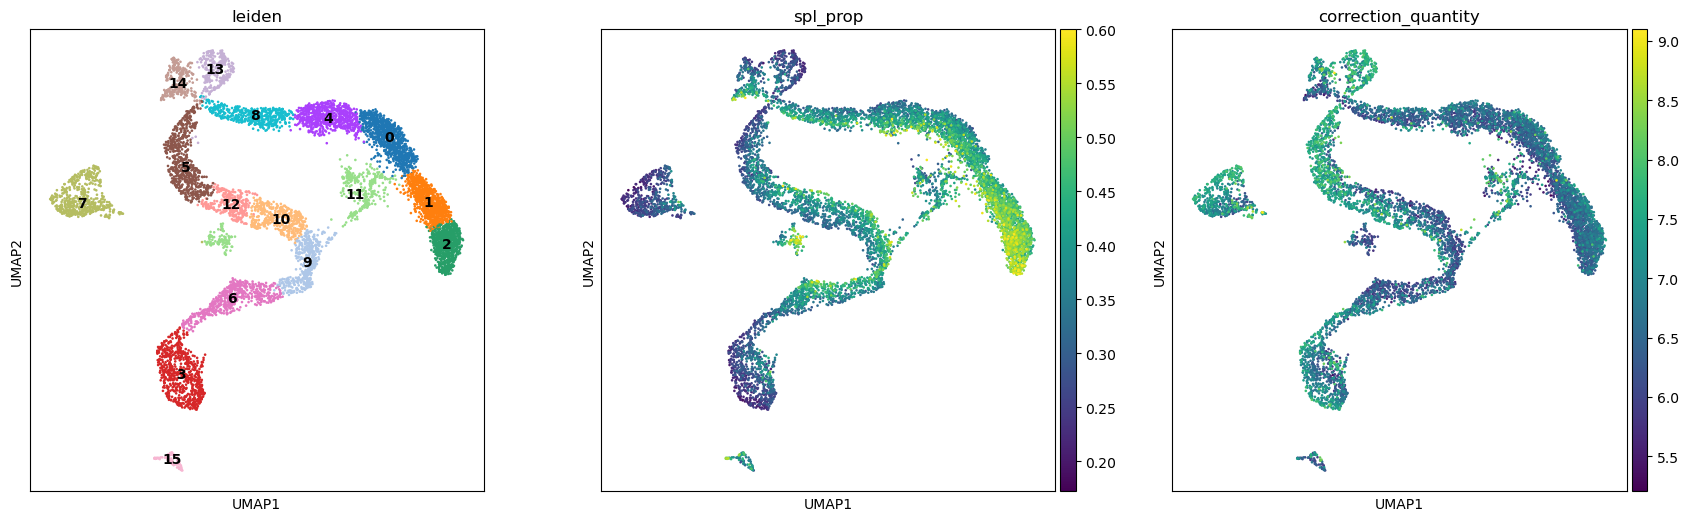

In [47]:
sc.pl.umap(adata2, color=['leiden','spl_prop','correction_quantity'], legend_loc='on data')

In [48]:
adata.layers['UMI-soupx'] = np.array( adata2.layers['UMI-soupx'] )

In [49]:
adata.obs['correction_quantity'] = adata2.obs['correction_quantity'].copy()

In [54]:
adata.obs['leiden'] = adata2.obs['leiden'].copy()

In [50]:
adata.obsm['X_umap'] = adata2.obsm['X_umap'].copy()

In [55]:
adata.write(f'./write/{sample}.flt.3.h5ad')

Set filtering and ckeck on UMAP

In [56]:
adata = sc.read(f'./write/{sample}.flt.3.h5ad')

Only considering the two last: ['.3', '.h5ad'].
Only considering the two last: ['.3', '.h5ad'].


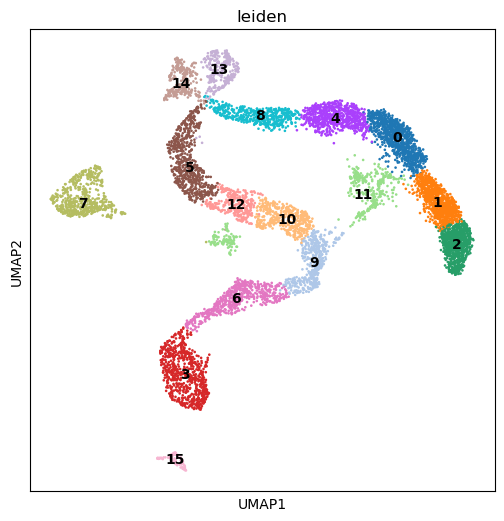

In [57]:
sc.pl.umap(adata, color=['leiden'], legend_loc='on data')

## Doublet filtering

In [58]:
sc.external.pp.scrublet(adata, 
                        expected_doublet_rate=0.04,
                        random_state=12345)

Automatically set threshold at doublet score = 0.12
Detected doublet rate = 6.7%
Estimated detectable doublet fraction = 71.1%
Overall doublet rate:
	Expected   = 4.0%
	Estimated  = 9.4%


In the code above, `random_state` is a number choosing how the simulations are done. Using a specific random state means that you will always simulate the same doublets whenever you run this code. This allows you to reproduce exactly the same results every time and is a great habit to have for reproducibility in your own research.

According to scrublet, the percentage of doublets is high. But we can see that most cells have a low score (the score is a value between 0 and 1). A score of 1 means a data point is a perfect doublet as from simulations. Datasets with many doublets show a more bimodal distribution (look for example at [this example](https://github.com/swolock/scrublet/blob/master/examples/scrublet_basics.ipynb) from the `scrublet` tutorial), while here we just have a slight peak beyond 0.1, where we set our threshold. 

In [59]:
%matplotlib inline

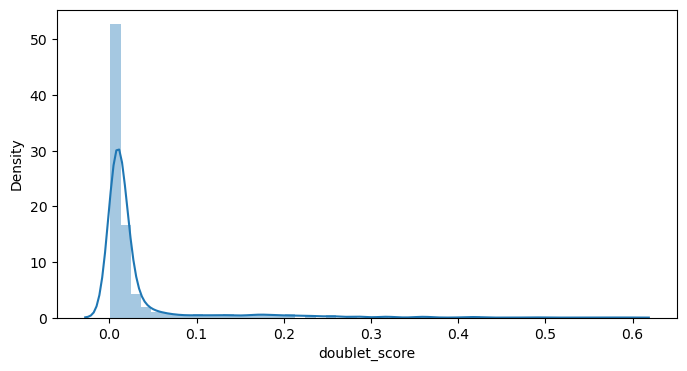

In [60]:
fig, ax = plt.subplots(1,1, figsize=(8,4))

fig1 = sns.distplot(adata.obs['doublet_score'])

In [61]:
adata = adata[ adata.obs['doublet_score']<0.1 ].copy()

In [62]:
print(f'Cells after doublet filter: {adata.shape[0]}, Genes after filters: {adata.shape[1]}')

Cells after doublet filter: 7840, Genes after filters: 24227


In [64]:
adata.write(f'./write/adata.flt.4.h5ad')

# Normalization

In [65]:
adata = sc.read(f'./write/adata.flt.4.h5ad')

Only considering the two last: ['.4', '.h5ad'].
Only considering the two last: ['.4', '.h5ad'].


In [66]:
adata.X = adata.layers['soupx_counts'].copy()

In [67]:
# Normalization and log-transformation for variance stabilization
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
# Selection of highly-variable genes
sc.pp.highly_variable_genes(adata)
# Z-score transformation
sc.pp.scale(adata, max_value=10)

In [68]:
adata.layers['soupx_Z_counts'] = adata.X.copy()

In [69]:
adata.write(f'./write/adata.norm.1.h5ad')

# PCA Projection + umap

In [70]:
adata = sc.read(f'./write/adata.norm.1.h5ad')

Only considering the two last: ['.1', '.h5ad'].
Only considering the two last: ['.1', '.h5ad'].


In [71]:
sc.pp.pca(adata, random_state=123)

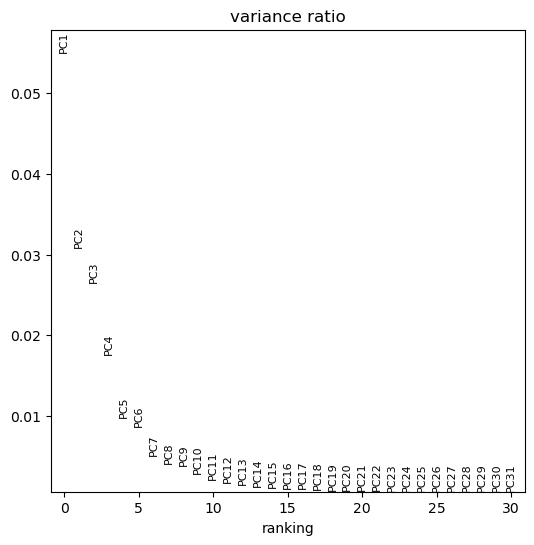

In [72]:
sc.pl.pca_variance_ratio(adata)

In [73]:
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=15, random_state=123)

In [74]:
sc.tl.umap(adata, random_state=123)

In [75]:
sc.tl.leiden(adata, resolution=.7, random_state=123)

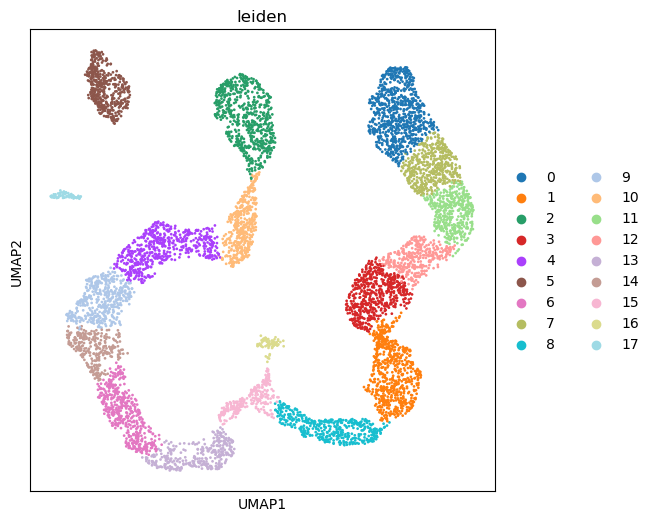

In [77]:
sc.pl.umap(adata, color=['leiden'], ncols=1)

In [78]:
adata.write(f'./write/adata.norm.topo.1.h5ad')

# Topometry

In [134]:
adata = sc.read(f'./write/adata.norm.topo.1.h5ad')

Only considering the two last: ['.1', '.h5ad'].
Only considering the two last: ['.1', '.h5ad'].


In [135]:
adata = adata[ [i not in ['16'] for i in adata.obs.leiden] ].copy()

In [136]:
adataHVG = adata[:, adata.var.highly_variable].copy()

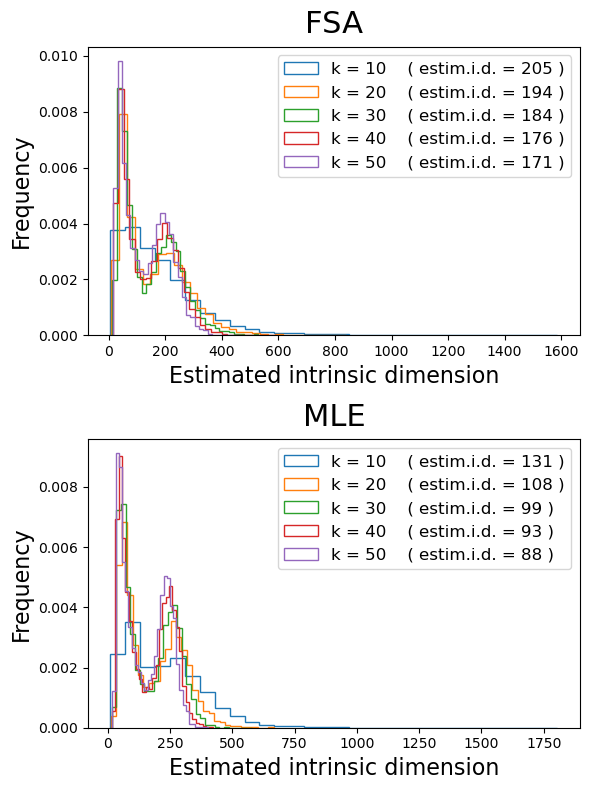

In [137]:
plt.rcParams["figure.figsize"] = (4, 4)
tp.tpgraph.IntrinsicDim(
    methods=["fsa", "mle"],
    k=range(10, 60, 10),
    backend="hnswlib",
    metric="euclidean",
    n_jobs=-1,
    plot=True,
    random_state=123,
).fit(adataHVG.X)

In [138]:
# Run TopOMetry

# Create a TopOGraph object with the desired parameters
tg = tp.TopOGraph(n_eigs=50, n_jobs=-1, verbosity=1, random_state=42)

# Fit some models to the data
adata = tp.sc.topological_workflow(
    adata,
    tg,
    kernels=["bw_adaptive"],
    eigenmap_methods=["LE","DM"],
    projections=["MAP", "PaCMAP"],
    resolution=0.5,
)

Computing neighborhood graph...
 Base kNN graph computed in 40.498826 (sec)
 Fitted the bw_adaptive kernel in 0.437047 (sec)
Computing eigenbasis...
 Fitted eigenbasis with Laplacian Eigenmaps from the bw_adaptive in 0.262106 (sec)
    Building topological graph from eigenbasis...
        Computing neighborhood graph...
 Computed in 0.193361 (sec)
 Fitted the bw_adaptive graph kernel in 0.425314 (sec)
 Computed MAP in 7.781514 (sec)
 Computed PaCMAP in 6.884145 (sec)
Computing eigenbasis...
 Fitted eigenbasis with Diffusion Maps from the bw_adaptive kernel in 0.149931 (sec)
    Building topological graph from eigenbasis...
        Computing neighborhood graph...
 Computed in 0.157403 (sec)
 Fitted the bw_adaptive graph kernel in 0.429304 (sec)
 Computed MAP in 7.172117 (sec)
 Computed PaCMAP in 6.750479 (sec)


In [139]:
adata.obsm["X_topoMAP_LE"] = adata.obsm["X_MAP of bw_adaptive from LE with bw_adaptive"]
adata.obsm["X_topoPaCMAP_LE"] = adata.obsm["X_PaCMAP of LE with bw_adaptive"]
adata.obs["topo_leiden_LE"] = adata.obs["bw_adaptive from LE with bw_adaptive_leiden"]

adata.obsm["X_topoMAP_DM"] = adata.obsm["X_MAP of bw_adaptive from DM with bw_adaptive"]
adata.obsm["X_topoPaCMAP_DM"] = adata.obsm["X_PaCMAP of DM with bw_adaptive"]
adata.obs["topo_leiden_DM"] = adata.obs["bw_adaptive from DM with bw_adaptive_leiden"]

adata.obsm["X_LE"] = adata.obsm["X_LE with bw_adaptive"]
adata.obsm["X_DM"] = adata.obsm["X_DM with bw_adaptive"]

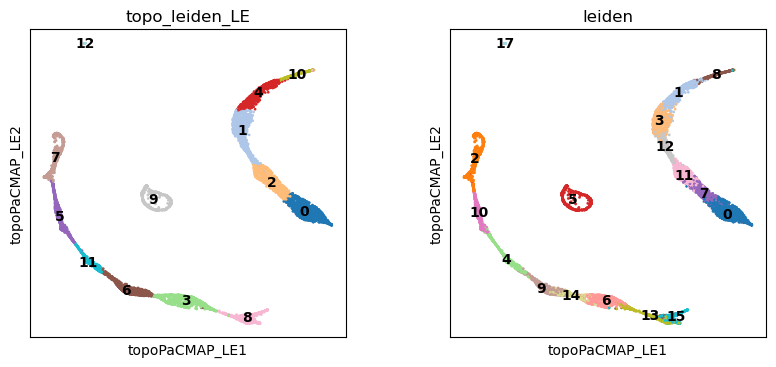

In [140]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoPaCMAP_LE",
    color=["topo_leiden_LE","leiden"],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
)

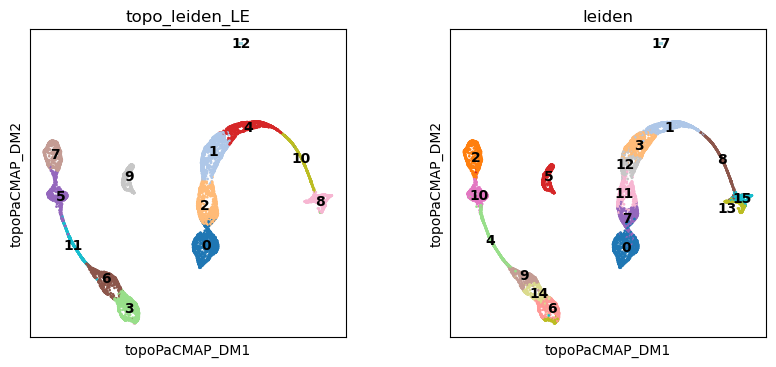

In [141]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoPaCMAP_DM",
    color=["topo_leiden_LE","leiden"],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
)

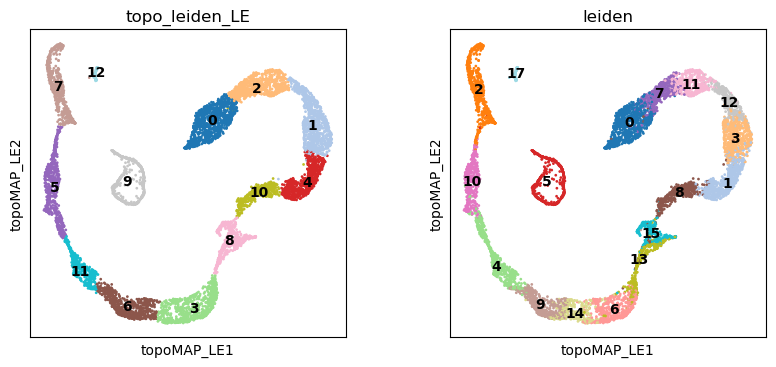

In [142]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoMAP_LE",
    color=["topo_leiden_LE","leiden"],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
)

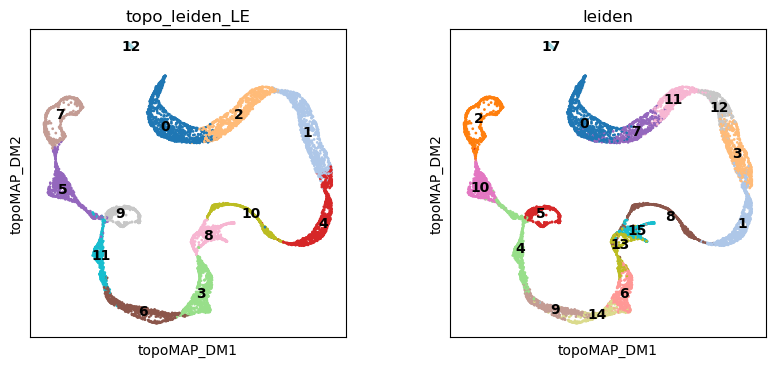

In [143]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoMAP_DM",
    color=["topo_leiden_LE","leiden"],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
)

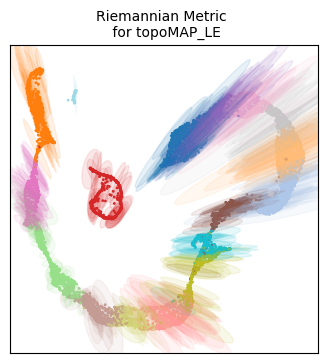

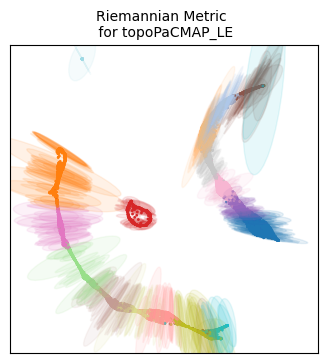

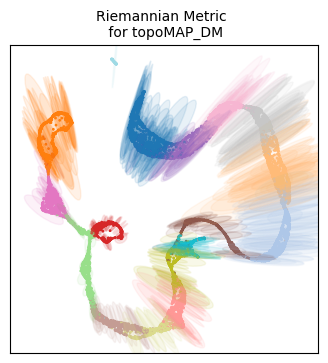

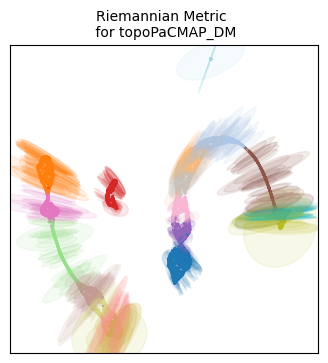

In [144]:
# Get the graph Laplacian of our base graph kernel:
L = tg.base_kernel.L

# Define how many ellipses to plot:
n_plot = 500

# Convert the labels to integers:
labels = adata.obs["leiden"].cat.codes


# Name the projections you want to plot:
projections = ["topoMAP_LE", "topoPaCMAP_LE", "topoMAP_DM", "topoPaCMAP_DM"]

# Plot the Riemann metric
for name in projections:
    xy_coord = adata.obsm["X_" + name][:, :2]
    tp.pl.plot_riemann_metric(
        xy_coord,  # The coordinates of the projection
        L,  # The graph Laplacian
        std=0.5,  # A scaling factor for the ellipses size
        n_plot=n_plot,  # How many ellipses to plot
        labels=labels,
        title=f"Riemannian Metric \n for {name}",
        cmap="tab20",  # For coloring
        random_state=tg.random_state,  # For coloring with same colors as before
        figsize=(4, 4),  # Size of the figure (NEEDS TO BE SQUARE!!!),
    )

In [145]:
adata.write(f'./write/adata.norm.topo.2.h5ad')

# Clustering

Assign scores simply with highest score pereach cluster done with Leiden

In [146]:
adata = sc.read(f'./write/adata.norm.topo.2.h5ad')

Only considering the two last: ['.2', '.h5ad'].
Only considering the two last: ['.2', '.h5ad'].


In [147]:
markers = dict()  # make an empty dictionary
### SPERMATOCYTOGENESIS
markers["SpermatogoniaA"] = ["ID4", "HMGA1","NANOS2","PAX7","ZBTB16","UTF1","FGFR3"]
markers["SpermatogoniaB"] = ["MKI67", "DMRT1", "STRA8","KIT"]
#markers["SpermatocytesI"] = ["MEIOB", "PRSS50", "SYCP1", "TEX101"]
#markers["SpermatocytesII"] = ["PIWIL1", "ACRV1", "SPATA16", "CLGN","GFRA1","ZBTB16","PGK2","ACR"]
### SPERMIOGENESIS
markers["Round.Spt"] = ["SPATA9", "SPAM1","WDR7","SLC16A7"]  # Round spermatids
markers["Elong.Spt"] = ["PRM1", "PRM2","TNP1","TNP2"]  # Elongated spermatids
### SOMATIC CELLS
markers["Sertoli"] = ["CTSL", "VIM", "GATA4"]
markers["Macroph"] = ["TYROBP"]
#markers["Leydig"] = ["CFD"]
markers["Endothelial"] = ["CD34"]
markers["Myoid"] = ["ACTA2"]
markers["Smooth_Muscle"] = ["RGS5"]
### Subclusters
markers['Leptotene'] = ['SCML1']
markers['Zygotene'] = ['SYCP1','LY6K']
markers['Pachytene'] = ['CCDC112','PIWIL1','TCFL5','MLH1','MLH3']
markers['Diplotene'] = ['CCNA1','AURKA','CDK1']

In [148]:
markers_scores, adata = marker_score(markers, adata)

In [149]:
adata

AnnData object with n_obs × n_vars = 7762 × 24227
    obs: 'spl_prop', 'uns_prop', 'perc_rp', 'perc_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'perc_PRM1', 'perc_PRM2', 'perc_LOC104001214', 'perc_KEF41-p07', 'perc_KEF41-p04', 'perc_MTRNR2L14', 'genes_threshold_filter', 'all_filters', 'correction_quantity', 'leiden', 'doublet_score', 'predicted_doublet', 'bw_adaptive from LE with bw_adaptive_leiden', 'bw_adaptive from DM with bw_adaptive_leiden', 'topo_leiden_LE', 'topo_leiden_DM', 'SpermatogoniaA_score', 'SpermatogoniaB_score', 'Round.Spt_score', 'Elong.Spt_score', 'Sertoli_score', 'Macroph_score', 'Endothelial_score', 'Myoid_score', 'Smooth_Muscle_score', 'Leptotene_score', 'Zygotene_score', 'Pachytene_score', 'Diplotene_score'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts

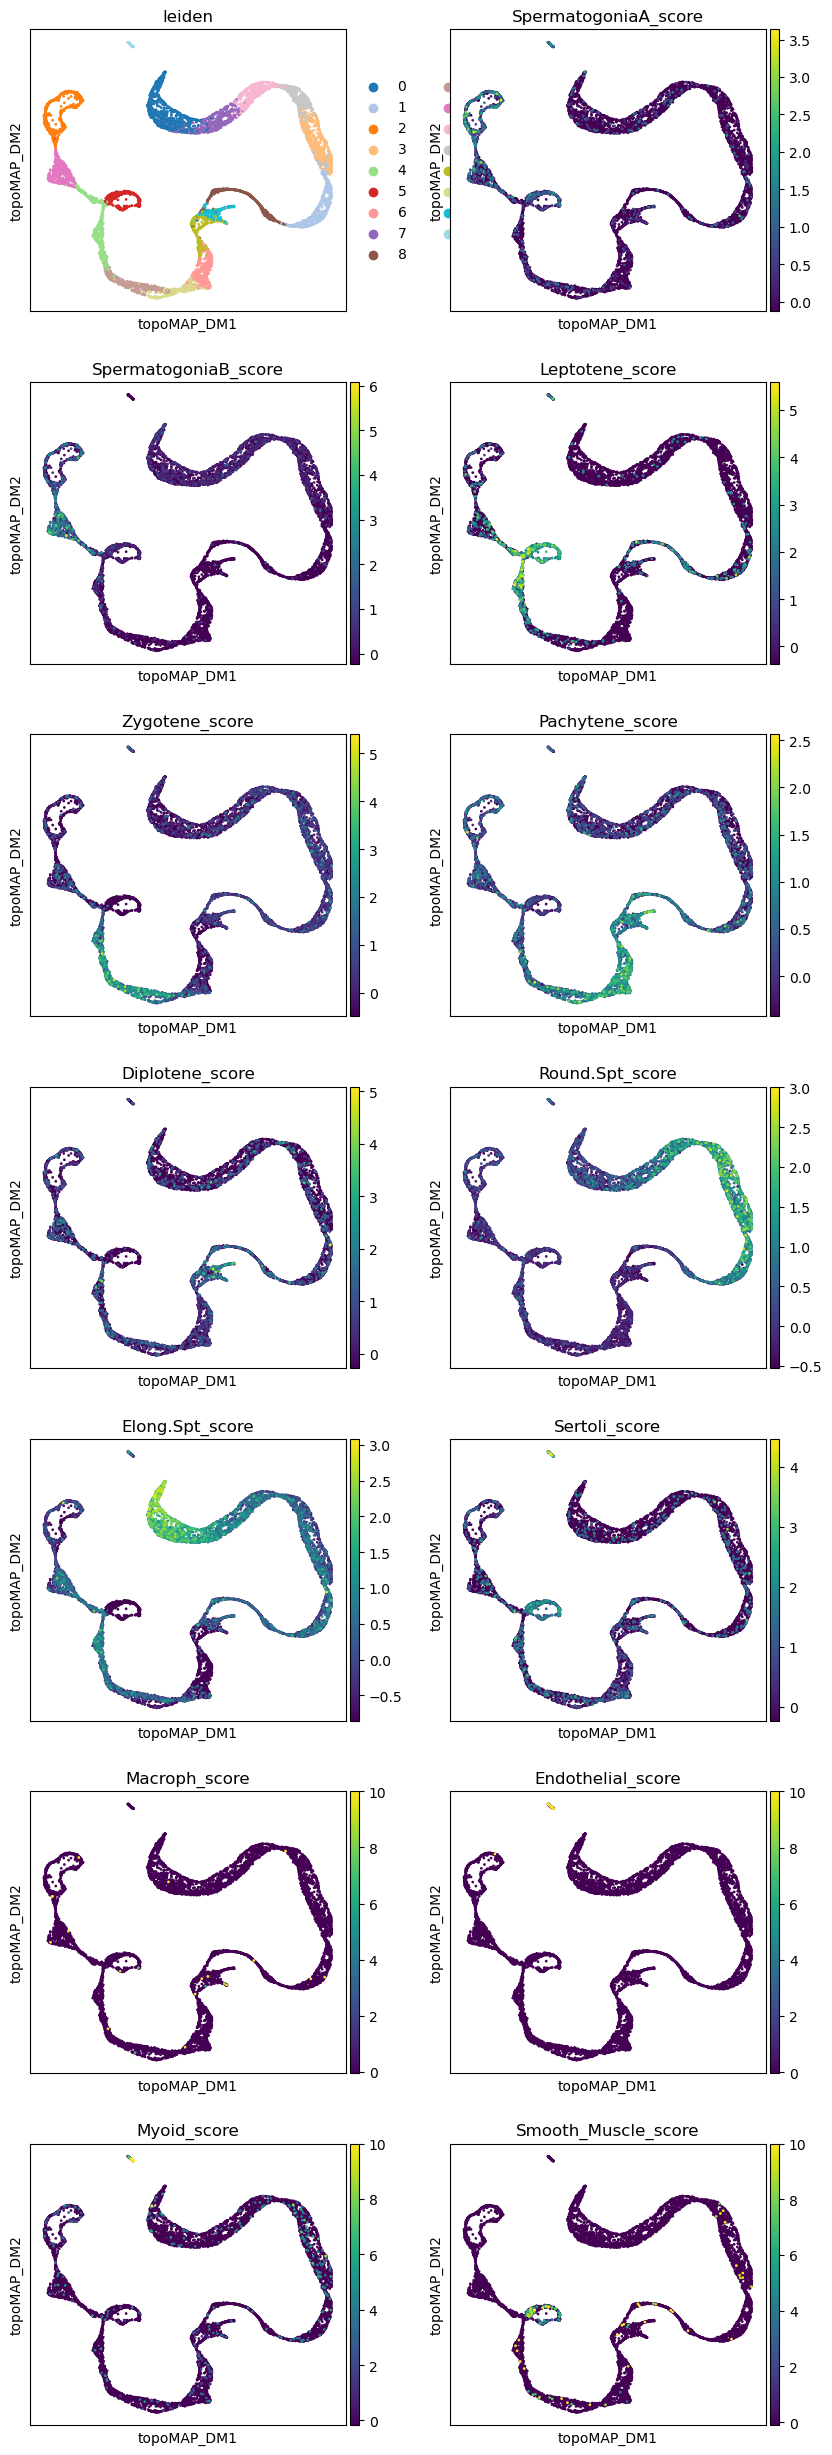

In [154]:
sc.pl.embedding(
    adata,
    basis="topoMAP_DM",
    color=["leiden", "SpermatogoniaA_score", "SpermatogoniaB_score", 'Leptotene_score', 
           'Zygotene_score', 'Pachytene_score', 'Diplotene_score', 'Round.Spt_score', 'Elong.Spt_score',
           'Sertoli_score', 'Macroph_score', 'Endothelial_score', 'Myoid_score', 'Smooth_Muscle_score'],
    palette="tab20",
    ncols=2,
    legend_fontsize=10,
)

In [155]:
adata.obs["clusters_single"] = clustersByScores(
    adata, markers_scores, leidenClusters=adata.obs["leiden"]
)

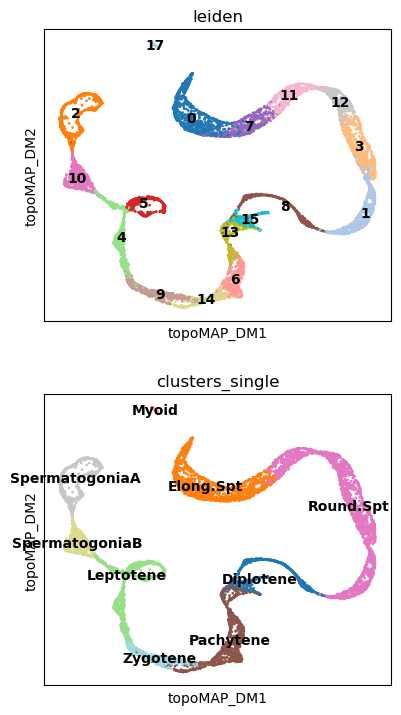

In [156]:
sc.pl.embedding(
    adata,
    basis="topoMAP_DM",
    color=["leiden", "clusters_single"],
    legend_loc="on data",
    palette="tab20",
    ncols=1,
    legend_fontsize=10,
)

In [157]:
adata.write(f'./write/adata.norm.topo.clst.h5ad')